**Cisplatin FF Parameterized via FUERZA Estimation & Subsequent Gradient Optimization**

Cisplatin toy example

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools
from sklearn.metrics import r2_score

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

#src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
from q2mm.hybrid_optimizer import PSO_DE
from tools.plotters import plot_cost_history, plot_contour, plot_surface, plot_summary, Mesher, Designer

from tools.ff_plotting import *



METHODS

In [2]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]


In [3]:
convergence_criteria = 0.001
num_params = 31

In [4]:
# Gather data on starting point

fuerza_score = 107.7652
static_score = 270.4237

fuerza_grad_score = 1.7479
normal_grad_score = 1.7479

fuerza_label = '{0:.3f}'.format(590.5287)
static_label = '{0:.3f}'.format(260)

fuerza_grad_label = '{0:.3f}'.format(1.7479)
normal_grad_label = '{0:.3f}'.format(1.7479)

score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391]

fuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
fuerza_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_grad_score))
static_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/eig_static.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Static: '+str(static_score))
normal_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/score.static.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(0))

bond_rows = np.arange(1860, 1863)
angle_rows = np.arange(1863, 1869)

#bond_fuerza = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/results/fuerza_grad/rh_hyd_enamide_q_seminario.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
#angle_fuerza = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/results/fuerza_grad/rh_hyd_enamide_q_seminario.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)

base_direc = '/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza'
direc = ''

bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, [direc], 'frankenfuerza_H.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')

bond_fuerza = bond_fuerza[0]
angle_fuerza = angle_fuerza[0]

bond_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_score)
angle_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_score)

bond_normal_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.static.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
angle_normal_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.static.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)

bond_normal = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/1-q/mm3.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
angle_normal = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/1-q/mm3.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)


/tmp/ipykernel_1351778/536652846.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
/tmp/ipykernel_1351778/536652846.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fuerza_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_grad_score))
/tmp/ipykernel_1351778/536652846.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  static_scores = pd.read_csv('/home/m

                                Label  Weight  Reference  Calculated    Score  \
0      eig_cisplatin_opt_freq_m06_1-1    0.00     3.0057      5.4396   0.0000   
1      eig_cisplatin_opt_freq_m06_2-1    0.05     0.0000      0.0140   0.0000   
2      eig_cisplatin_opt_freq_m06_2-2    0.10     3.9943      2.3712   0.0001   
3      eig_cisplatin_opt_freq_m06_3-1    0.05     0.0000     -3.9757   0.0001   
4      eig_cisplatin_opt_freq_m06_3-2    0.05     0.0000     -0.0397   0.0000   
..                                ...     ...        ...         ...      ...   
373  eig_cisplatin_opt_freq_m06_27-23    0.05     0.0000      0.0795   0.0000   
374  eig_cisplatin_opt_freq_m06_27-24    0.05     0.0000    -10.1401   0.0007   
375  eig_cisplatin_opt_freq_m06_27-25    0.05     0.0000    -10.4111   0.0007   
376  eig_cisplatin_opt_freq_m06_27-26    0.05     0.0000      1.1333   0.0000   
377  eig_cisplatin_opt_freq_m06_27-27    0.10  4682.5991   3842.6453  18.6646   

                   FF  
0  

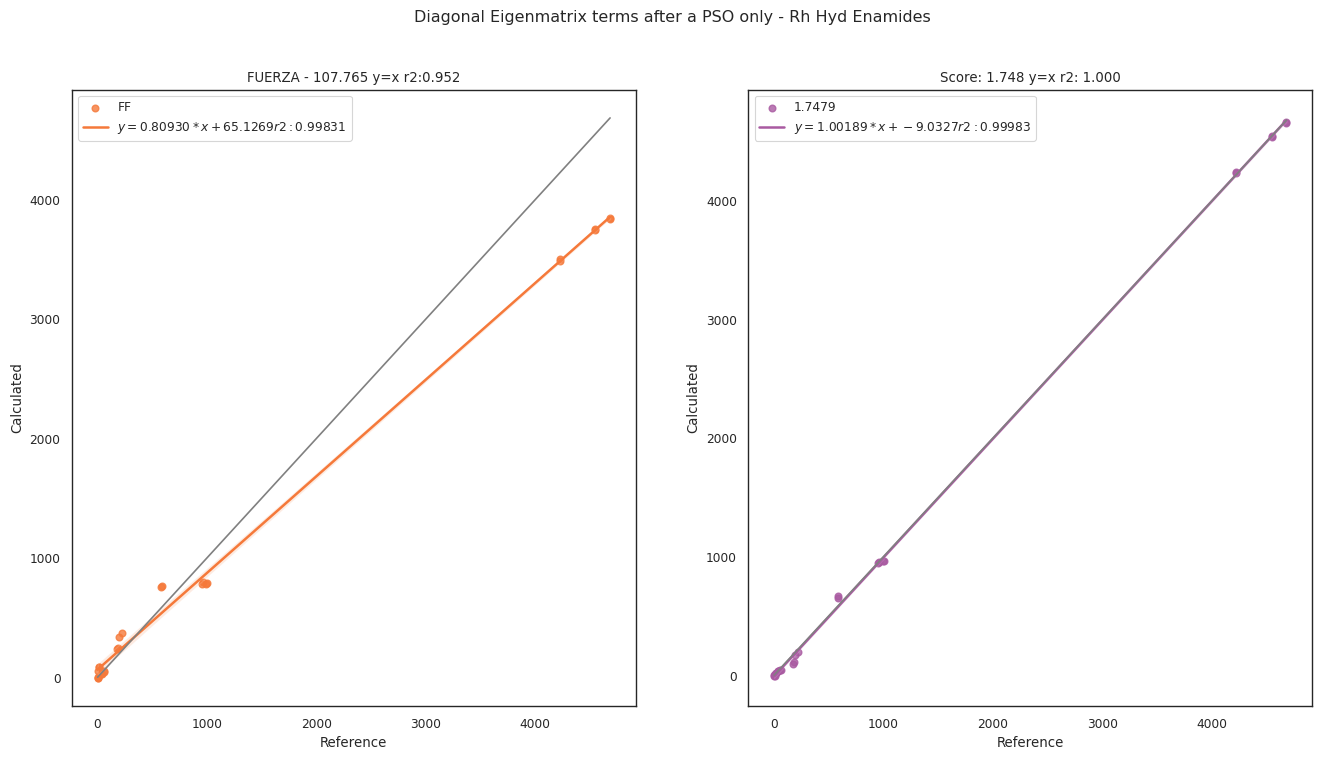

In [5]:
# linear fit diag scores comparison
%matplotlib inline

print(fuerza_scores)
print(fuerza_grad_scores)

linear_fit_diag_scores(fuerza_scores, fuerza_score, [fuerza_grad_scores], [fuerza_grad_score], 'Diagonal Eigenmatrix Before & After GRAD starting from FUERZA estimate')

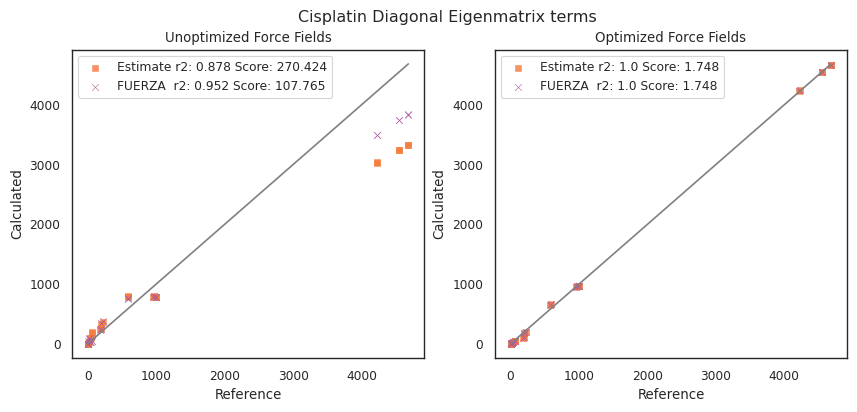

In [6]:
seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix terms')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

c1 = next(palette)
c2 = next(palette)

diag_start = static_scores.loc[static_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(static_score, decimals=3)), ax=ax[0], marker='s', alpha = 0.8)

diag_start = fuerza_scores.loc[fuerza_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(fuerza_score, decimals=3)), ax=ax[0], marker='x')
ax[0].legend()
ax[0].set_title('Unoptimized Force Fields')

diag_end = normal_grad_scores.loc[normal_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(normal_grad_score, decimals=3)), ax=ax[1], marker='s', alpha=0.8)

diag_end = fuerza_grad_scores.loc[fuerza_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(fuerza_grad_score, decimals=3)), ax=ax[1], marker='x')
ax[1].legend()
ax[1].set_title('Optimized Force Fields')

for a in ax:
    seaborn.lineplot(data=diag_start, x='Reference', y='Reference', color='gray', ax=a)

In [7]:
indices_to_check = diag_start.loc[diag_start['Calculated'] - diag_start['Reference'] > 250]
print(indices_to_check)

Empty DataFrame
Columns: [Label, Weight, Reference, Calculated, Score, FF]
Index: []


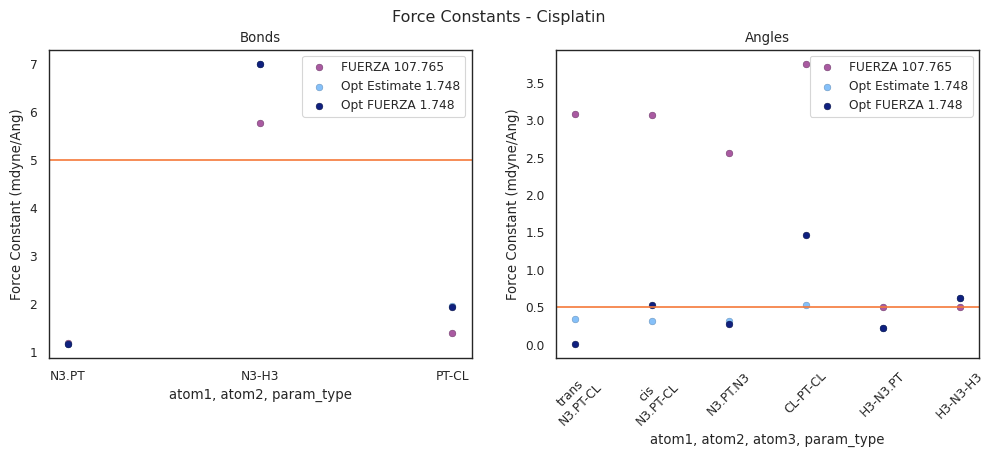

In [ ]:
bonds = [bond_fuerza, bond_normal_grad, bond_fuerza_grad]
angles = [angle_fuerza, angle_normal_grad, angle_fuerza_grad]
scores = [fuerza_score, normal_grad_score, fuerza_grad_score]
scores = ['FUERZA '+'{0:.3f}'.format(fuerza_score), 'Opt Estimate '+'{0:.3f}'.format(normal_grad_score), 'Opt FUERZA '+'{0:.3f}'.format(fuerza_grad_score)]
bond_label_list = ['plt.legend(bbox_to_anchor=(1.05, 1))N3.PT', 'N3-H3', 'PT-CL']
angle_label_list = ['trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']
fig, ax = plot_ff_params_v_static(bonds, angles, scores, ' - Cisplatin', bond_labels=bond_label_list, angles_labels=angle_label_list)

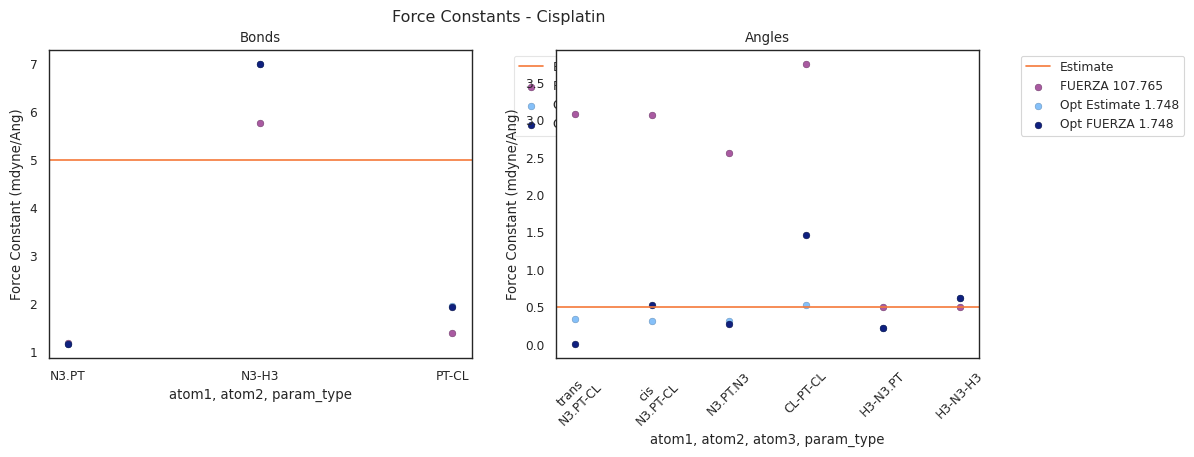

In [5]:
bonds = [bond_fuerza, bond_normal_grad, bond_fuerza_grad]
angles = [angle_fuerza, angle_normal_grad, angle_fuerza_grad]
scores = [fuerza_score, normal_grad_score, fuerza_grad_score]
scores = ['FUERZA '+'{0:.3f}'.format(fuerza_score), 'Opt Estimate '+'{0:.3f}'.format(normal_grad_score), 'Opt FUERZA '+'{0:.3f}'.format(fuerza_grad_score)]
bond_label_list = ['N3.PT', 'N3-H3', 'PT-CL']
angle_label_list = ['trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']
fig, ax = plot_ff_params_v_static(bonds, angles, scores, ' - Cisplatin', bond_labels=bond_label_list, angles_labels=angle_label_list)

In [6]:
gamma_angle_fuerza = angle_fuerza.copy()
gamma_angle_fuerza['Force Constant'] = angle_fuerza['Force Constant'] * 0.68
gamma_angle_fuerza

,param_type,atom1,atom2,atom3,Equilibrium Value,Force Constant,FF,ff_row
0,2,1,2,3,178.8085,2.090116,107.7652,1864
1,a2,1,2,3,83.7330,2.086376,107.7652,1865
2,2,1,2,N3,97.4580,1.741480,107.7652,1866
3,2,Cl,2,3,95.0750,2.549796,107.7652,1867
4,2,H3,1,2,110.4200,0.340000,107.7652,1868
5,2,H3,1,H3,108.3540,0.340000,107.7652,1869


In [ ]:
def custom_param_plot(bonds:list, final_scores:list, title:str='', bond_labels=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    fig.suptitle('Force Constants'+title)

    palette = itertools.cycle(zesty_palette)
    edges = itertools.cycle(zesty2_palette)
    
    color=next(palette)
    edge=next(edges)
    ax[0].axhline(5, color=color)
    ax[1].axhline(0.5, color=color)

    if bond_labels is None:
        bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
        bond_labels = [str(bl) for bl in bond_labels]
    if angles_labels is None:
        angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
        angles_labels = [str(al) for al in angles_labels]
    for i in range(len(bonds)):
        color = next(palette)
        edge = next(edges)
        seaborn.scatterplot(data=bonds[i], label=final_scores[i], x = bond_labels, y="Force Constant", edgecolor=edge, ax=ax[0], color=color)


    plt.xticks(rotation=45)
    ax[0].legend()
    ax[1].legend()
    ax[0].set_ylabel('Force Constant (mdyne/Ang)')
    ax[1].set_ylabel('Force Constant (mdyne/Ang)')
    plt.show()
    return fig, ax


IndexError: list index out of range

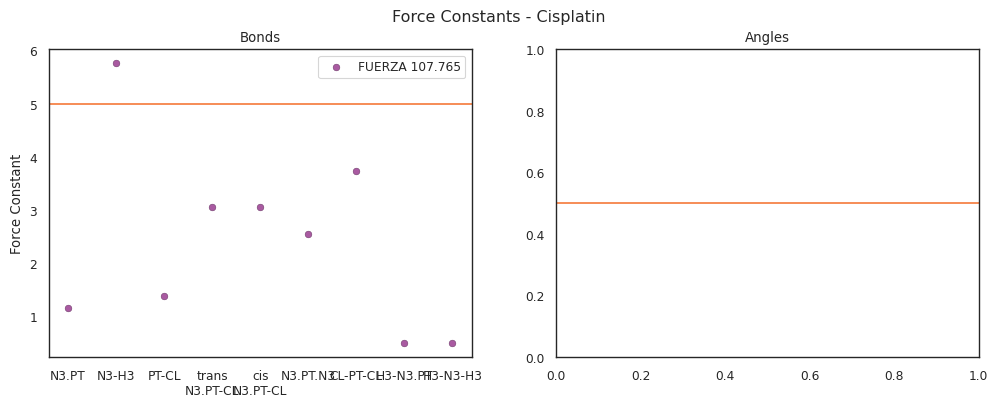

In [ ]:
bonds = [bond_fuerza, bond_normal_grad, bond_fuerza_grad]
angles = [angle_fuerza, angle_normal_grad, angle_fuerza_grad]
input = [bond_fuerza.append(angle_fuerza), bond_normal_grad.append(angle_normal_grad), bond_fuerza_grad.append(angle_fuerza_grad)]
scores = ['FUERZA '+'{0:.3f}'.format(fuerza_score), 'Opt Estimate '+'{0:.3f}'.format(normal_grad_score), 'Opt FUERZA '+'{0:.3f}'.format(fuerza_grad_score)]
bond_label_list = ['N3.PT', 'N3-H3', 'PT-CL','trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']
fig, ax = plot_ff_params_v_static(input, [], scores, ' - Cisplatin', bond_labels=bond_label_list, angles_labels=angle_label_list)